In [1]:
from Scripts.Random_forest_nested import *
import pickle
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox', 'scaled_no2', 'scaled_formaldehyd', 'scaled_acetone',
       'scaled_acetald', 'scaled_bc', 'scaled_PM25', 'no2_street', 'nox_street',
       'pm25_street', 'bmi_6_yrs', 'gestational_age', 'mother\'s_education_1yr',
       'lrti_1y', 'genetic_risk_score_asthma', 'PCA1', 'PCA2']],df.verificeret_18y
NUM_TRIALS=2

In [3]:
list_parameters=["$NO_x$","$NO_2$","Formaldehyd","Acetone","Acetald","Black Carbon","$PM_{2.5}$","Street $NO_2$","Street $NO_x$","Street $PM_{2.5}$","BMI","Gestational age","Mother Education",'LRTI',"Asthma risk score","Landuse 1","Landuse 2"]


In [4]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [5]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(10, 30),
    'max_features':           [0.4, 0.5, 0.6, 'sqrt'],
    'max_samples':            [0.5, 0.6, 0.7, 0.8],
    # class_weight removed
}
dataframe=nested_cross_calibrated_rf(
    X, y,
    Number_CV=2,
    number_split=3,
    n_neighbors_imputer=25,
    param_distributions=param_distributions,
    calibration_method="isotonic")

Fold 1/6  AUC=0.622  BSS=+0.044  ICI=0.024
Fold 2/6  AUC=0.590  BSS=+0.029  ICI=0.024
Fold 3/6  AUC=0.488  BSS=-0.079  ICI=0.083
Fold 4/6  AUC=0.620  BSS=+0.033  ICI=0.020
Fold 5/6  AUC=0.449  BSS=-0.058  ICI=0.091
Fold 6/6  AUC=0.543  BSS=+0.004  ICI=0.043


In [6]:
with open("../Performence/results_rf_18y_adjusted.pkl", "wb") as f:
    pickle.dump(dataframe, f)

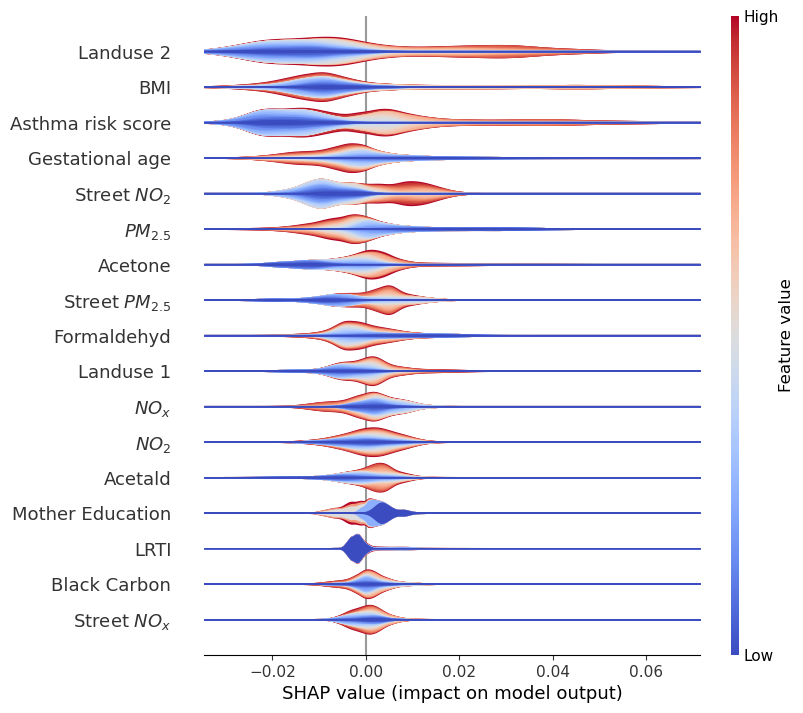

In [8]:
fig=shap.plots.violin(dataframe['shap_values_oof'],X ,plot_type="layered_violin",show=False,max_display=30)
plt.savefig('../Plots/shap_18_adjusted.png',dpi=300,bbox_inches='tight')
